<a href="https://colab.research.google.com/github/ahmadfa100/-Ahmad-bani-Hamad/blob/main/CCN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install rarfile

In [2]:
import os
import rarfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
class Config:
    """إعدادات النموذج والتدريب"""
    # مسار ملف البيانات المضغوط (RAR)
    RAR_PATH = 'xray_dataset_covid19.rar'
    EXTRACTED_PATH = 'xray_dataset_covid19'

    # معاملات الصور
    IMG_HEIGHT = 224
    IMG_WIDTH = 224
    IMG_CHANNELS = 1

    # معاملات التدريب
    BATCH_SIZE = 32
    EPOCHS = 10
    LEARNING_RATE = 0.0001

    # الفئات
    CLASSES = ['NORMAL', 'PNEUMONIA']
    NUM_CLASSES = len(CLASSES)

    # مسارات الحفظ
    MODEL_SAVE_PATH = 'covid19_xray_model.h5'
    WEIGHTS_SAVE_PATH = 'covid19_xray_weights.h5'
    HISTORY_SAVE_PATH = 'training_history.npy'

config = Config()

In [5]:

# ==============================
# 2. فك ضغط البيانات (تلقائياً)
# ==============================

def extract_rar_dataset():
    """
    فك ضغط مجموعة البيانات إذا لم تكن مفكوكة بالفعل
    """
    if not os.path.exists(config.EXTRACTED_PATH):
        print("\n📦 جاري فك ضغط البيانات من ملف RAR...")
        rf = rarfile.RarFile(config.RAR_PATH)
        rf.extractall('.')  # فك الضغط في نفس المجلد
        print("✅ تم فك الضغط بنجاح!\n")
    else:
        print("✅ تم العثور على مجلد البيانات مفكوك مسبقاً.\n")


In [6]:
# ==============================
# 3. تحضير البيانات مع Data Augmentation
# ==============================

def create_data_generators():
    """
    إنشاء مولدات البيانات مع تطبيق Data Augmentation على بيانات التدريب
    """
    TRAIN_DIR = os.path.join(config.EXTRACTED_PATH, 'train')
    TEST_DIR = os.path.join(config.EXTRACTED_PATH, 'test')

    # مولد بيانات التدريب مع تحسينات متعددة
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest',
        validation_split=0.2
    )

    test_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(config.IMG_HEIGHT, config.IMG_WIDTH),
        color_mode='grayscale',
        batch_size=config.BATCH_SIZE,
        class_mode='binary',
        subset='training',
        shuffle=True
    )

    validation_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(config.IMG_HEIGHT, config.IMG_WIDTH),
        color_mode='grayscale',
        batch_size=config.BATCH_SIZE,
        class_mode='binary',
        subset='validation',
        shuffle=False
    )

    test_generator = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=(config.IMG_HEIGHT, config.IMG_WIDTH),
        color_mode='grayscale',
        batch_size=config.BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )

    return train_generator, validation_generator, test_generator


In [7]:
# ==============================
# 4. بناء نموذج CNN احترافي
# ==============================

def build_cnn_model():
    """بناء نموذج CNN احترافي"""
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=(config.IMG_HEIGHT, config.IMG_WIDTH, 1)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Flatten + Dense Layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        # Output Layer
        layers.Dense(1, activation='sigmoid')
    ])
    return model


In [8]:
# ==============================
# 5. تجميع النموذج
# ==============================

def compile_model(model):
    optimizer = optimizers.Adam(learning_rate=config.LEARNING_RATE)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall(), keras.metrics.AUC()]
    )
    return model


In [9]:
# ==============================
# 6. Callbacks
# ==============================

def create_callbacks():
    return [
        callbacks.ModelCheckpoint(config.MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        callbacks.CSVLogger('training_log.csv'),
    ]


In [10]:
# ==============================
# 7. تدريب النموذج
# ==============================

def train_model(model, train_gen, val_gen, cb_list):
    print("\n🚀 بدء التدريب...\n")
    history = model.fit(
        train_gen,
        epochs=config.EPOCHS,
        validation_data=val_gen,
        callbacks=cb_list,
        verbose=1
    )
    np.save(config.HISTORY_SAVE_PATH, history.history)
    return history


In [11]:
# ==============================
# 8. تقييم النموذج
# ==============================

def evaluate_model(model, test_gen):
    print("\n تقييم النموذج...\n")
    test_loss, test_acc, test_precision, test_recall, test_auc = model.evaluate(test_gen, verbose=1)
    print(f"\n النتائج:\nAccuracy: {test_acc:.4f}\nLoss: {test_loss:.4f}\nPrecision: {test_precision:.4f}\nRecall: {test_recall:.4f}\nAUC: {test_auc:.4f}")
    return test_acc



In [12]:
# ==============================
# 10. التنبؤ وتحليل النتائج
# ==============================

def predict_and_analyze(model, test_gen):
    print("\n التنبؤ على بيانات الاختبار...\n")

    # التنبؤ بالفئات
    y_pred_prob = model.predict(test_gen)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = test_gen.classes

    # تقرير التصنيف
    print("\n📄 تقرير التصنيف:")
    print(classification_report(y_true, y_pred, target_names=config.CLASSES))

    # مصفوفة الارتباك
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=config.CLASSES,
                yticklabels=config.CLASSES)
    plt.title('📊 مصفوفة الارتباك (Confusion Matrix)')
    plt.xlabel('الفئة المتوقعة')
    plt.ylabel('الفئة الحقيقية')
    plt.show()

In [13]:
def main():
    print("\n" + "="*60)
    print(" نموذج CNN للكشف عن COVID-19 من صور الأشعة السينية ")
    print("="*60 + "\n")

    # فك الضغط
    extract_rar_dataset()

    # تحضير البيانات
    train_gen, val_gen, test_gen = create_data_generators()

    # بناء وتجميع النموذج
    model = compile_model(build_cnn_model())

    # التدريب
    history = train_model(model, train_gen, val_gen, create_callbacks())

    # التقييم
    evaluate_model(model, test_gen)
    #predict
    predict_and_analyze(model, test_gen)

    # حفظ النموذج
    model.save(config.MODEL_SAVE_PATH)
    print(f"\n تم حفظ النموذج في: {config.MODEL_SAVE_PATH}")



 نموذج CNN للكشف عن COVID-19 من صور الأشعة السينية 


📦 جاري فك ضغط البيانات من ملف RAR...
✅ تم فك الضغط بنجاح!

Found 120 images belonging to 2 classes.
Found 28 images belonging to 2 classes.
Found 40 images belonging to 2 classes.

🚀 بدء التدريب...

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5918 - auc: 0.6828 - loss: 0.8152 - precision: 0.5793 - recall: 0.6719 
Epoch 1: val_accuracy improved from None to 0.50000, saving model to covid19_xray_model.h5



Epoch 1: finished saving model to covid19_xray_model.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 56s 9s/step - accuracy: 0.6750 - auc: 0.7889 - loss: 0.7530 - precision: 0.6615 - recall: 0.7167 - val_accuracy: 0.5000 - val_auc: 0.5867 - val_loss: 0.7382 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.8266 - auc: 0.9095 - loss: 0.5301 - precision: 0.8638 - recall: 0.8084
Epoch 2: val_accuracy did not improve from 0.50000
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8583 - auc: 0.9194 - loss: 0.4713 - precision: 0.8644 - recall: 0.8500 - val_accuracy: 0.5000 - val_auc: 0.4643 - val_loss: 0.9042 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.8771 - auc: 0.9552 - loss: 0.3086 - precision: 0.9012 - recall: 0.8733
Epoch 3: val_accuracy did not improve from 0.50000
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 932ms/step - accuracy: 0.8750 - au

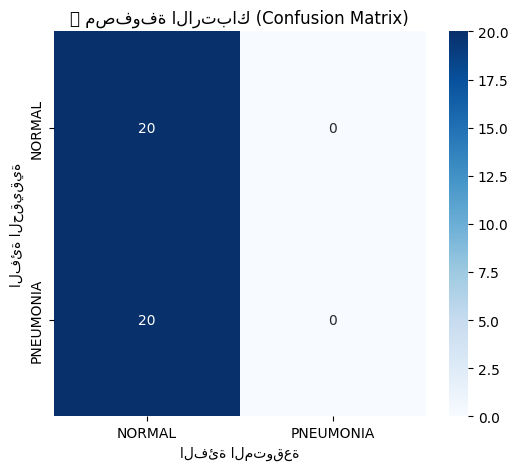


 تم حفظ النموذج في: covid19_xray_model.h5


In [15]:


# ==============================
# تشغيل البرنامج
# ==============================

if __name__ == "__main__":
    main()
